In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import shap

d:\cproject\b-tech-course-project\synthetic data\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
df = pd.read_csv("synthetic_subsidy_cylinders1.csv")


      Age  Gender  Marital_Status  Household_Size  Governorate   Salary  \
27   18.0       1               1               3            1   171.03   
64   52.0       1               0               3            1   102.86   
98   40.0       1               1               6            2   149.24   
202  61.0       0               1               5            1    80.00   
290  22.0       0               2               9            3   100.53   
313  43.0       0               0               4            1    80.00   
333  34.0       0               1               4            2   131.19   
512  58.0       0               0               4            4  1410.47   
597  18.0       0               2               4            3  1536.59   
599  20.0       0               2               5            1   868.80   
629  59.0       1               2               5            2   818.75   
630  27.0       0               1               6            1  1801.62   
640  53.0       0        

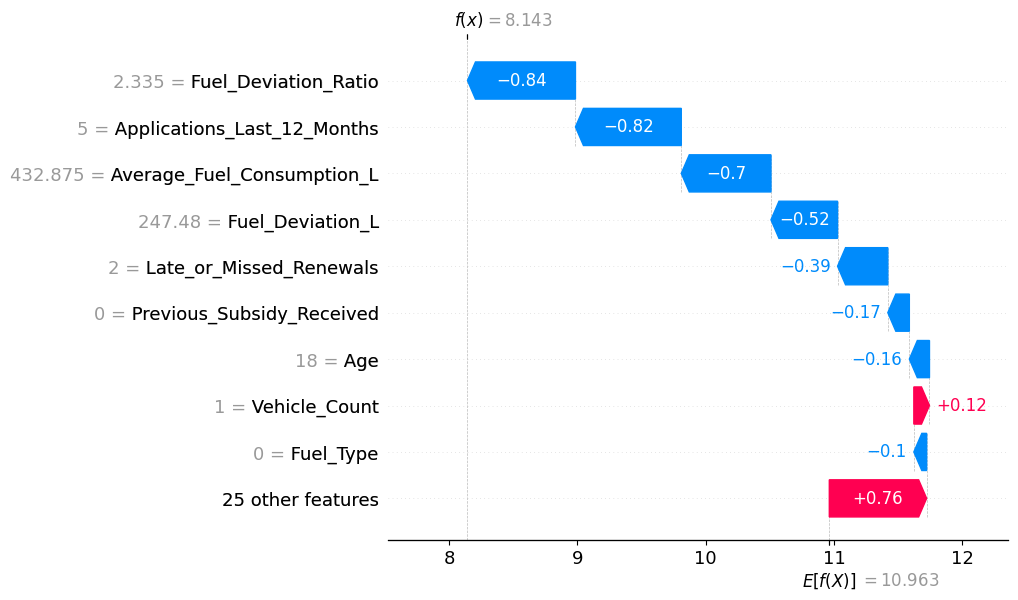

        Age    Gender  Marital_Status  Household_Size  Governorate    Salary  \
0  0.158598 -0.043388         0.12674        0.072823     0.087036 -0.208724   

   Degree_Level  Employment_Status  Primary_Income_Source  \
0      0.040267          -0.127083               0.107898   

   Has_Other_Social_Benefits  ...  Expected_Fuel_Consumption_L  \
0                   0.125597  ...                    -0.024598   

   Average_Fuel_Consumption_L  Fuel_Deviation_L  Fuel_Deviation_Ratio  \
0                   -0.022876         -0.007691              -0.31607   

   Previous_Subsidy_Received  Previous_Subsidy_Amount  \
0                  -0.100258                  0.00098   

   Late_or_Missed_Renewals  Applications_Last_12_Months  Eligible        ID  
0                 0.009054                     0.030746 -0.135933  0.038386  

[1 rows x 32 columns] Assets_Value
['Assets_Value', 'Fuel_Deviation_Ratio', 'Vehicle_Ownership']


In [ ]:
#scaler = StandardScaler().fit_transform(df.loc[:,df.columns!='Fraud'])
X=df.drop(columns=["Fraud",'ID'])

model = IsolationForest(contamination=0.02, random_state=42)
model.fit(X)
X["anomaly_score"]=model.predict(X)
X['Fraud'] = X['anomaly_score'].apply(lambda x: 1 if x == -1 else 0)
print(X.loc[(X["Fraud"]>0) | (X["Fraud"]<0)])




explainer = shap.Explainer(model, X)
shap_values = explainer(X)
print(shap_values[27])
# 3. Visualize for a specific "Under Review" applicant
# Let's say index 5 was flagged as fraud
shap.plots.waterfall(shap_values[27])
# Isolate the specific row first
row_to_explain = X.loc[X["ID"] == 11432416].drop(columns=["anomaly_score", "Fraud"])

# Call the explainer on that row
row_shap_values = explainer(row_to_explain,check_additivity=False)

column_names = X.columns.drop(["anomaly_score", "Fraud"])
adf=pd.DataFrame(columns=column_names ,data=row_shap_values.values)
print(adf,adf.min().idxmin())
print(adf.iloc[0].sort_values(ascending=True).head(3).index.tolist())


In [ ]:
model()